> **Data Availability Notice**  
> This analysis uses a retrospective clinical dataset that cannot be shared publicly due to patient privacy and ethical restrictions.  
> The notebook demonstrates methodology, analysis flow, and interpretation.


In [1]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Rheah\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Rheah\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [3]:
df.shape

(193, 130)

In [4]:
print("Number of columns:", len(df.columns))
print(df.columns.tolist())

Number of columns: 130
['UHID', 'Age', 'Date of Surgery', 'Date of Dischrge', 'Length of Stay', 'Height in cm', 'Weight in kg', 'BMI (F)', 'BMI', 'Comorbidities', 'DRE', 'Clinical Stage', 'D AMICO Risk', 'TURP/HOLEP-Yes/Nil ', 'Pre OP Hormone Treatment', 'Pre Op-USG', 'Pre Op-MRI', 'Pre-OP PSMA PET Scan', 'PSMA Avid Node or Mets positivity on Scan', 'SUV MAX Value', 'Biopsy Remark By PI', 'Gleason Score in Pre-OP Biopsy ', 'No. of Cores Right', 'No. of Cores Left', 'Total No. of Positive Cores', 'Maximum Percentage of Cores', 'Robot', 'Console - Start Time', 'Console - End Time', 'Console Time in hrs', 'Console Time in Minutes(For)', 'Console Time in Minutes', 'Bladder Neck Sparing', 'Rocco', 'PDS versus V loc', 'Suspension', 'Conventional', 'Retzius Sparing', 'Detrussor Apron Preservation 1/2/3', 'Interfascial/ Intrafascial/ Extrafascial', 'Nerve Sparing', 'Median Lobe', 'Lymph Node', 'Peritoneal Incision Open/Closed', 'Hemoststic Agent', 'Specimen Inked-Yes/No', ' Intra OP-Complicati

In [5]:

df['Fincar Administrated'] = df['Fincar Administrated'].str.strip().replace({'\xa0Ye': 'Yes', 'Ye': 'Yes'})



print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (193, 130)


In [6]:
df['Gleason score (HPR)'] = df['Gleason score (HPR)'].str.strip()

# Mapping different versions to consistent categories
gleason_mapping = {
    '3+3': '3+3',
    '3+3=6': '3+3',
    '3+4': '3+4',
    '3+4=7': '3+4',
    '3 + 4= 7/10': '3+4',
    '4+3': '4+3',
    '4+3=7': '4+3',
    '4 + 3 = 7': '4+3',
    '4+4': '4+4',
    '4+4=8': '4+4',
    '3+5': '3+5',
    '4+5': '4+5',
    '4+5 = 10': '4+5',
    '5+4 = 9/10': '5+4'
}

df['Gleason_cleaned'] = df['Gleason score (HPR)'].map(gleason_mapping)

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(f"Number of numerical columns: {len(num_cols)}")
print(num_cols)

sns.set(style="whitegrid", palette="muted", color_codes=True)



Number of numerical columns: 10
Index(['Age', 'Length of Stay', 'Height in cm', 'Weight in kg', 'BMI (F)',
       'BMI', 'Console Time in Minutes(For)', 'Console Time in Minutes',
       'Post-OP Hb', 'PSA before fincar '],
      dtype='object')


## Distribution of Key Numerical Variables

The following plots summarize the distributions of clinically relevant 
numerical variables used in subsequent survival and outcome analyses.


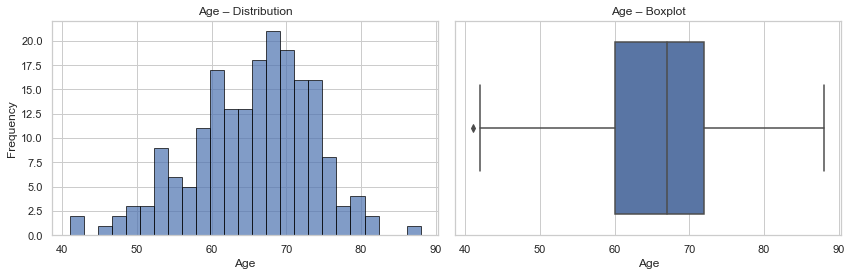

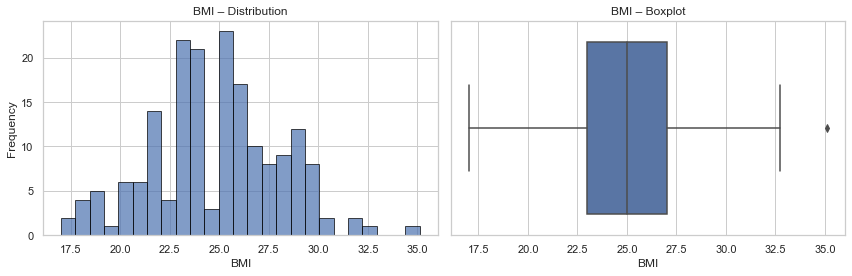

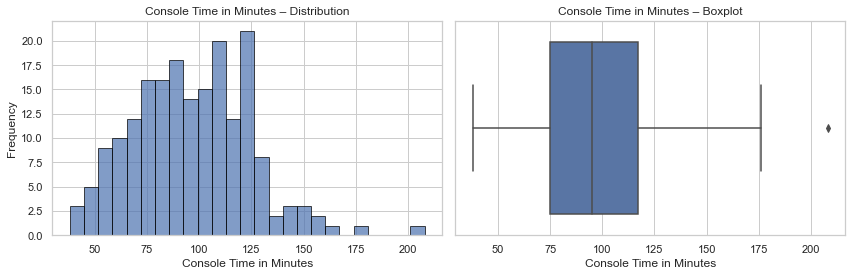

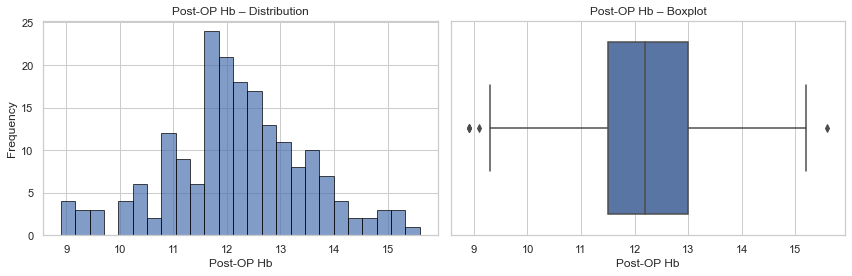

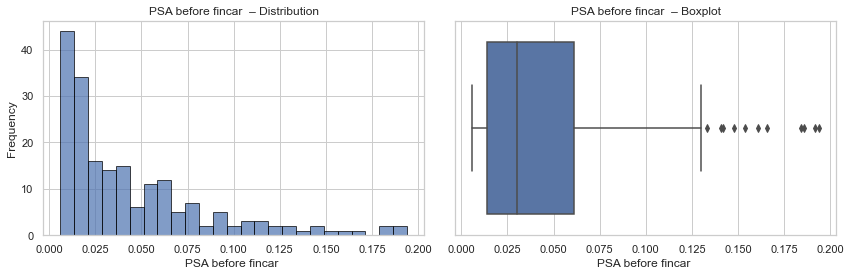

In [23]:
eda_num_cols = [
    "Age",
    "BMI",
    "Console Time in Minutes",
    "Post-OP Hb",
    "PSA before fincar "
]

sns.set(style="whitegrid")

for col in eda_num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(
        df[col].dropna(),
        bins=25,
        edgecolor="black",
        alpha=0.7
    )
    axes[0].set_title(f"{col} – Distribution")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    # Boxplot
    sns.boxplot(
        x=df[col],
        ax=axes[1]
    )
    axes[1].set_title(f"{col} – Boxplot")

    plt.tight_layout()
    plt.show()

In [9]:


cat_cols = df.select_dtypes(include=['object']).columns

print(f"Number of categorical columns: {len(cat_cols)}")
print(cat_cols)




Number of categorical columns: 118
Index(['UHID', 'Date of Dischrge', 'Comorbidities', 'DRE', 'Clinical Stage',
       'D AMICO Risk', 'TURP/HOLEP-Yes/Nil ', 'Pre OP Hormone Treatment',
       'Pre Op-USG', 'Pre Op-MRI',
       ...
       'Failure Durarion (Month)', 'Hormone after Fincar Administrartiuon',
       'TABI after Fincar Administrartiuon',
       'Dutas after Fincar Administrartiuon', 'Biochemical Recurrence 2',
       'Reccurence durtion', 'Treatment after Recurrence',
       'Adjuvant Treatment-Hormone 2', 'Adjuvant Treatment -RT 2',
       'Gleason_cleaned'],
      dtype='object', length=118)


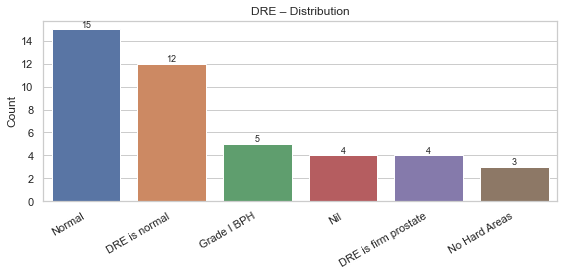

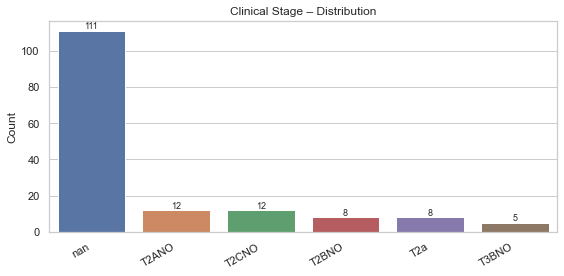

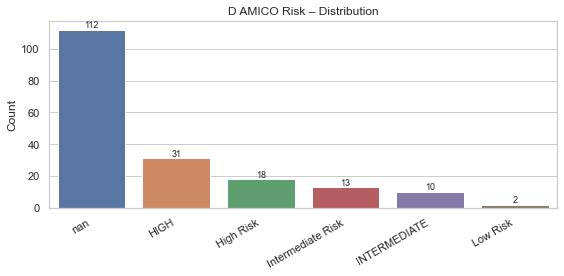

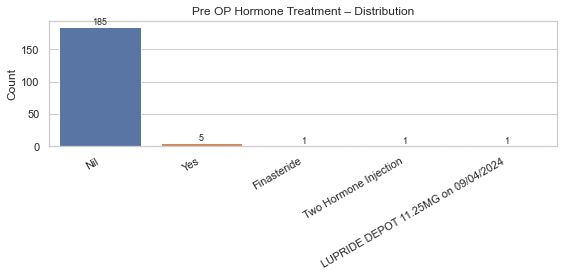

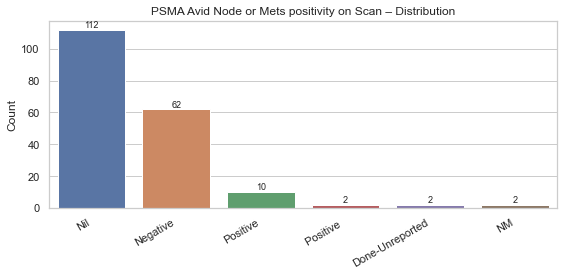

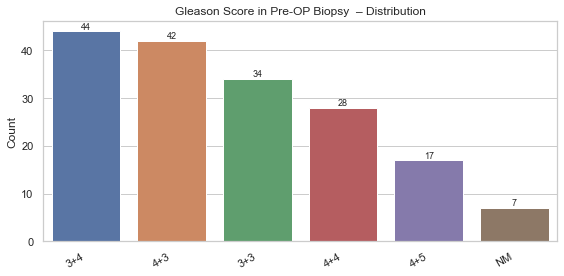

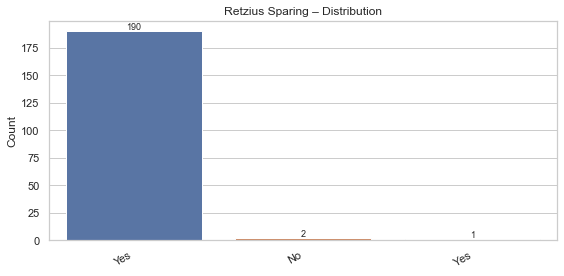

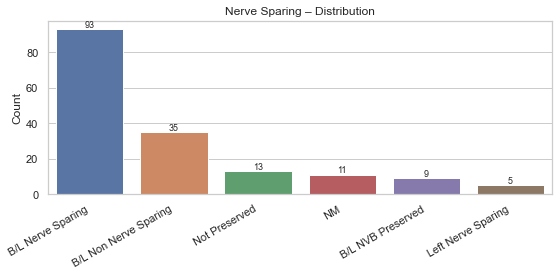

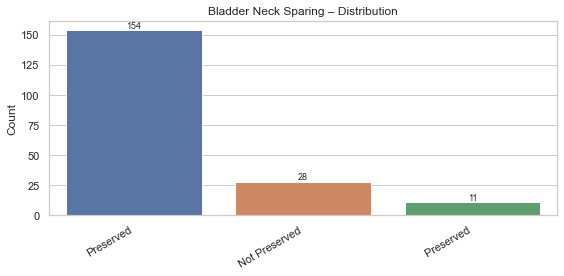

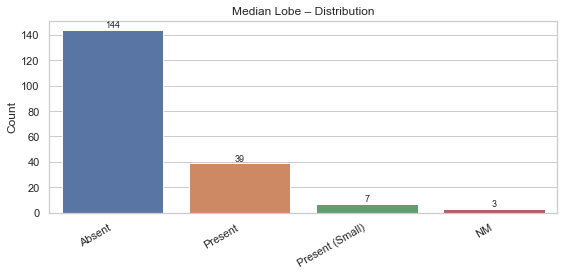

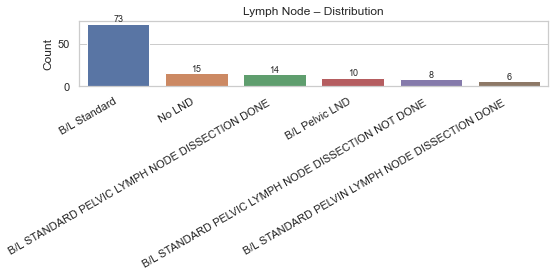

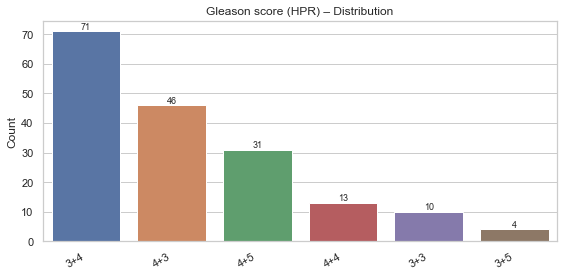

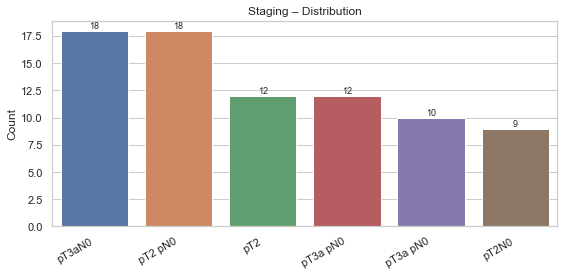

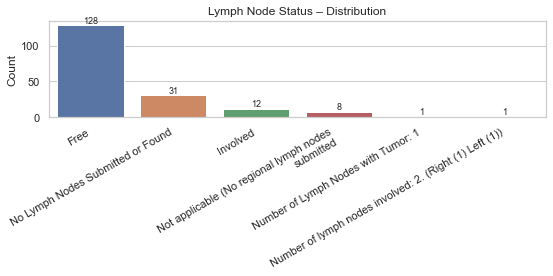

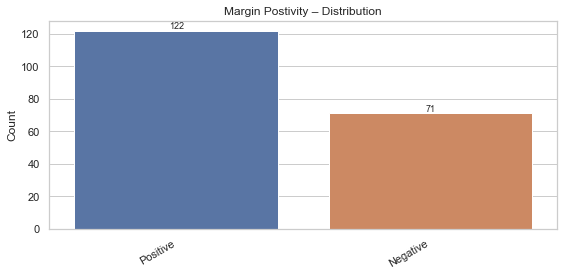

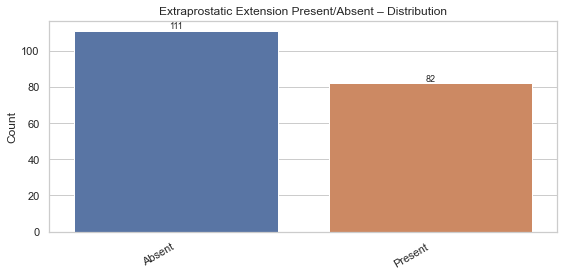

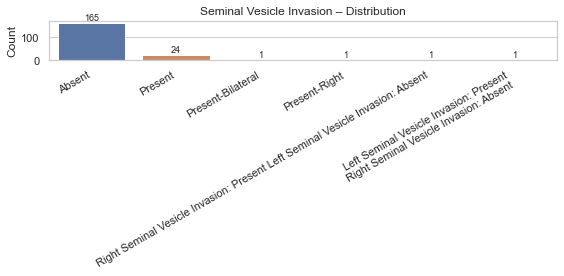

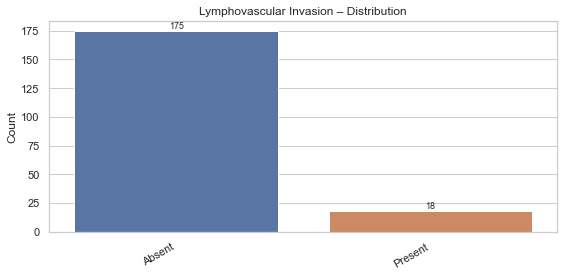

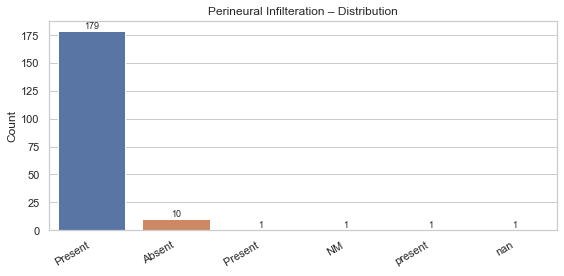

C:\Users\Rheah\anaconda3\lib\site-packages\seaborn\categorical.py:257: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  g_vals = grouped_vals.get_group(g)


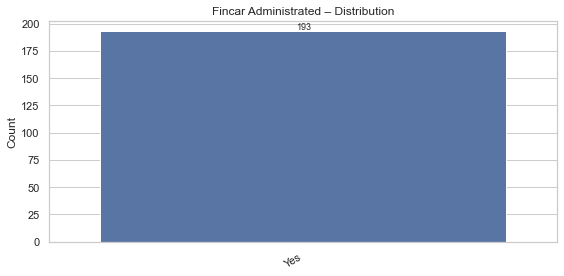

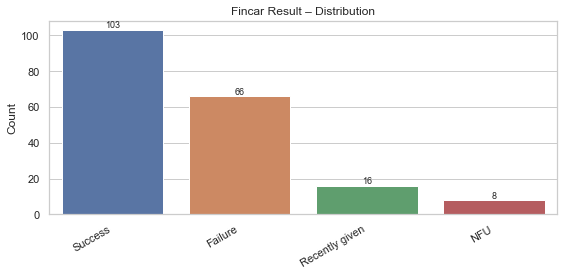

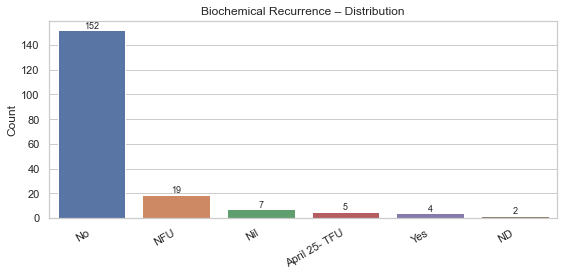

In [25]:


sns.set(style="whitegrid")

eda_cat_cols = [
    "DRE",
    "Clinical Stage",
    "D AMICO Risk",
    "Pre OP Hormone Treatment",
    

    "PSMA Avid Node or Mets positivity on Scan",
    
    "Gleason Score in Pre-OP Biopsy ",
    "Retzius Sparing",
    "Nerve Sparing",
    "Bladder Neck Sparing",
    "Median Lobe",
    "Lymph Node",
    "Gleason score (HPR)",
    "Staging",
    "Lymph Node Status",
    "Margin Postivity",
    "Extraprostatic Extension Present/Absent",
    "Seminal Vesicle Invasion",
    "Lymphovascular Invasion",
    "Perineural Infilteration",
    "Fincar Administrated",
    "Fincar Result",
    "Biochemical Recurrence"
]

for col in eda_cat_cols:
    counts = df[col].value_counts(dropna=False).nlargest(6)

    plt.figure(figsize=(8, 4))
    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values
    )

    plt.title(f"{col} – Distribution")
    plt.ylabel("Count")
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")

    for i, val in enumerate(counts.values):
        plt.text(i, val, f"{val}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()


In [11]:
df_num = df[num_cols]

## Correlation Analysis of Numerical Features

A correlation heatmap was generated to identify relationships and potential 
multicollinearity among key numerical variables. This helps guide feature 
selection and interpretation in downstream analyses.


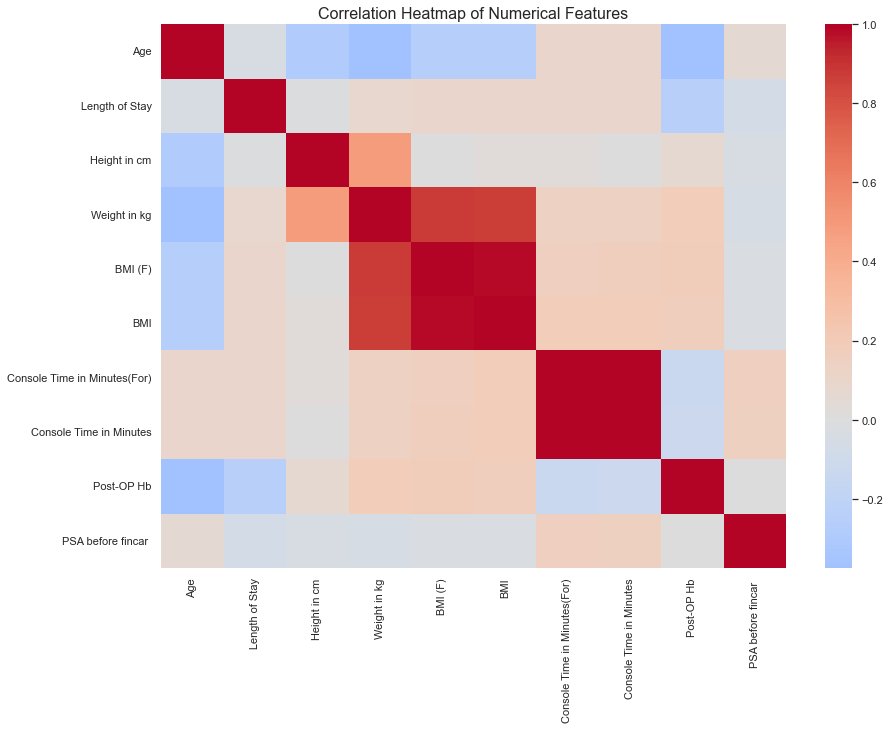

In [12]:
# Correlation Heatmap ----
plt.figure(figsize=(14, 10))
corr = df_num.corr(numeric_only=True)  # In case of mixed types
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.show()

## Outlier Detection

Statistical outlier detection was performed to understand the presence and 
extent of extreme values in numerical variables. Outliers were assessed but 
not removed, as they may represent clinically meaningful observations.


In [15]:
# ---- 2️⃣ Statistical Outlier Detection (IQR Method) ----
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers

print("\n=== IQR Method: Outlier Summary ===")
for col in eda_num_cols:
    outliers = detect_outliers_iqr(df[col].dropna())
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")




=== IQR Method: Outlier Summary ===
Age: 1 outliers (0.52%)
Length of Stay: 91 outliers (47.15%)
Weight in kg: 2 outliers (1.04%)
BMI (F): 1 outliers (0.52%)
BMI: 1 outliers (0.52%)
Console Time in Minutes(For): 2 outliers (1.04%)
Console Time in Minutes: 1 outliers (0.52%)
Post-OP Hb: 5 outliers (2.59%)
PSA before fincar : 11 outliers (5.70%)


### IQR Method

The Interquartile Range (IQR) method is robust to skewed distributions and was 
used as the primary approach for identifying potential outliers.


### Z-score Method (Sensitivity Analysis)

Z-score–based detection was performed as a secondary method to assess the 
sensitivity of outlier identification under a normality assumption.


In [16]:
#Statistical Outlier Detection (Z-score Method) ----
print("\n=== Z-score Method: Outlier Summary ===")
zscore_threshold = 3 

for col in eda_num_cols:
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outliers = col_zscore[col_zscore > zscore_threshold]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")



=== Z-score Method: Outlier Summary ===
Age: 1 outliers (0.52%)
Length of Stay: 5 outliers (2.59%)
Weight in kg: 1 outliers (0.52%)
BMI (F): 1 outliers (0.52%)
BMI: 1 outliers (0.52%)
Console Time in Minutes(For): 2 outliers (1.04%)
Console Time in Minutes: 1 outliers (0.52%)
PSA before fincar : 4 outliers (2.07%)
